**Appendix**

In [ ]:
#Load necessary packages
library(tidyverse)
library(dplyr)
library(ggplot2)
install.packages("pheatmap")
install.packages("corrplot")
library(pheatmap)
library(corrplot)
install.packages("GGally")
library(GGally)
install.packages("vcd")
install.packages("reshape2")
library(vcd)
library(reshape2)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

corrplot 0.95 loaded

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘patchwork’, ‘ggstats’, ‘plyr’


Warning message in install.packages("GGally"):
“installation of package ‘plyr’ had non-zero exit status”
Warning message in install.package

ERROR: Error in library(GGally): there is no package called ‘GGally’


In [ ]:
# Load the dataset
dataset <- read.csv("/content/work_hours.csv")

# View the first few rows
head(dataset)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
,<int>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,52,Private,98926,HS-grad,9,Never-married,Other-service,Unmarried,White,Male,-3,0,44,United-States,<=50K
2,76,Self-emp-not-inc,132607,Bachelors,12,Married-civ-spouse,Sales,Husband,White,Male,7527,0,44,United-States,>50K
3,40,Private,243258,Bachelors,13,Married-civ-spouse,Transport-moving,Husband,Amer-Indian-Eskimo,Male,19,0,57,United-States,>50K
4,76,State-gov,181259,Bachelors,12,Married-civ-spouse,Prof-specialty,Husband,White,Male,7720,0,44,United-States,>50K
5,36,Self-emp-inc,115379,Masters,13,Divorced,Exec-managerial,Not-in-family,White,Male,12,0,58,United-States,<=50K
6,24,Private,274505,Bachelors,12,Never-married,Prof-specialty,Own-child,White,Female,2,0,40,United-States,<=50K


In [ ]:
str(dataset)

'data.frame':	18944 obs. of  15 variables:
 $ age           : int  52 76 40 76 36 24 40 42 37 52 ...
 $ workclass     : chr  " Private" " Self-emp-not-inc" " Private" " State-gov" ...
 $ fnlwgt        : int  98926 132607 243258 181259 115379 274505 80789 243759 67638 130237 ...
 $ education     : chr  " HS-grad" " Bachelors" " Bachelors" " Bachelors" ...
 $ education.num : int  9 12 13 12 13 12 8 10 12 8 ...
 $ marital.status: chr  " Never-married" " Married-civ-spouse" " Married-civ-spouse" " Married-civ-spouse" ...
 $ occupation    : chr  " Other-service" " Sales" " Transport-moving" " Prof-specialty" ...
 $ relationship  : chr  " Unmarried" " Husband" " Husband" " Husband" ...
 $ race          : chr  " White" " White" " Amer-Indian-Eskimo" " White" ...
 $ sex           : chr  " Male" " Male" " Male" " Male" ...
 $ capital.gain  : int  -3 7527 19 7720 12 2 13 18 4 0 ...
 $ capital.loss  : int  0 0 0 0 0 0 0 0 0 1 ...
 $ hours.per.week: int  44 44 57 44 58 40 35 39 39 55 ...
 $ native

In [ ]:
summary(dataset)

      age         workclass             fnlwgt        education        
 Min.   :14.00   Length:18944       Min.   :  8019   Length:18944      
 1st Qu.:28.00   Class :character   1st Qu.: 98531   Class :character  
 Median :40.00   Mode  :character   Median :152896   Mode  :character  
 Mean   :39.27                      Mean   :164292                     
 3rd Qu.:47.00                      3rd Qu.:215541                     
 Max.   :99.00                      Max.   :772988                     
 education.num    marital.status      occupation        relationship      
 Min.   : 2.000   Length:18944       Length:18944       Length:18944      
 1st Qu.: 8.000   Class :character   Class :character   Class :character  
 Median : 9.000   Mode  :character   Mode  :character   Mode  :character  
 Mean   : 9.479                                                           
 3rd Qu.:12.000                                                           
 Max.   :16.000                               

In [ ]:
nrow(dataset)

[1] 18944

In [ ]:
# Check if there are any missing values in the dataset
colSums(is.na(dataset))

age      workclass         fnlwgt      education  education.num 
             0              0              0              0              0 
marital.status     occupation   relationship           race            sex 
             0              0              0              0              0 
  capital.gain   capital.loss hours.per.week native.country         income 
             0              0              0              0              0

In [ ]:
# Check for duplicate rows in the dataset
duplicated_rows <- sum(duplicated(dataset))
duplicated_rows

[1] 0

In [ ]:
# Check Unique Categories for All Categorical Variables
lapply(dataset[, sapply(dataset, function(x) is.factor(x) | is.character(x))], unique)

$workclass
[1] " Private"          " Self-emp-not-inc" " State-gov"       
[4] " Self-emp-inc"     " Federal-gov"      " Local-gov"       
[7] " Never-worked"     " Without-pay"     

$education
 [1] " HS-grad"      " Bachelors"    " Masters"      " Some-college"
 [5] " 7th-8th"      " Doctorate"    " Prof-school"  " Assoc-voc"   
 [9] " Assoc-acdm"   " 5th-6th"      " 11th"         " 9th"         
[13] " 1st-4th"      " 12th"         " 10th"         " Preschool"   

$marital.status
[1] " Never-married"         " Married-civ-spouse"    " Divorced"             
[4] " Married-spouse-absent" " Separated"             " Widowed"              
[7] " Married-AF-spouse"    

$occupation
 [1] " Other-service"     " Sales"             " Transport-moving" 
 [4] " Prof-specialty"    " Exec-managerial"   " Adm-clerical"     
 [7] " Handlers-cleaners" " Farming-fishing"   " Craft-repair"     
[10] " Protective-serv"   " Machine-op-inspct" " Tech-support"     
[13] " Priv-house-serv"   " Armed-Forces"     

$relationship
[1] " Unmarried"      " Husband"        " Not-in-family"  " Own-child"     
[5] " Wife"           " Other-relative"

$race
[1] " White"              " Amer-Indian-Eskimo" " Asian-Pac-Islander"
[4] " Black"              " Other"             

$sex
[1] " Male"   " Female"

$native.country
 [1] " United-States"              " Cuba"                      
 [3] " Philippines"                " Mexico"                    
 [5] " Honduras"                   " Jamaica"                   
 [7] " England"                    " India"                     
 [9] " Canada"                     " Puerto-Rico"               
[11] " South"                      " Guatemala"                 
[13] " Haiti"                      " Iran"                      
[15] " Outlying-US(Guam-USVI-etc)" " El-Salvador"               
[17] " Italy"                      " Cambodia"                  
[19] " Germany"                    " Portugal"                  
[21] " Japan"                      " Yugoslavia"                
[23] " Ireland"                    " China"                     
[25] " Dominican-Republic"         " Taiwan"                    
[27] " Ecuador"                    " Poland"                    
[29] " Trinadad&Tobago"            " Vietnam"                   
[31] " Thailand"                   " Columbia"                  
[33] " Peru"                       " France"                    
[35] " Greece"                     " Hungary"                   
[37] " Laos"                       " Scotland"                  
[39] " Hong"                       " Nicaragua"                 
[41] " Holand-Netherlands"        

$income
[1] " <=50K" " >50K"

In [ ]:
# Remove rows with unnecessary categories (e.g."Never-worked")
dataset <- dataset %>% filter(!workclass %in% c(" Never-worked"))
table(dataset$workclass)


      Federal-gov         Local-gov           Private      Self-emp-inc 
              995              1159             11700               861 
 Self-emp-not-inc         State-gov       Without-pay 
             3089               819               258 

In [ ]:
# Re-categorized the work-class Variable
dataset$workclass <- recode(dataset$workclass,
                            " State-gov" = "Government",
                            " Federal-gov" = "Government",
                            " Local-gov" = "Government",
                            " Self-emp-not-inc" = "Self-employed",
                            " Self-emp-inc" = "Self-employed")

In [ ]:
table(dataset$workclass) # To confirm
sum(table(dataset$workclass))


      Private   Without-pay    Government Self-employed 
        11700           258          2973          3950 

[1] 18881

In [ ]:
# Re-categorized the education Variable
dataset$education <- recode(dataset$education,
                            " Some-college" = "school-level",
                            " 1st-4th" = "school-level",
                            " 5th-6th" = "school-level",
                            " 7th-8th" = "school-level",
                            " 9th" = "school-level",
                            " 10th" = "school-level",
                            " 11th" = "school-level",
                            " 12th" = "school-level",
                            " Preschool" = "school-level",
                            " Prof-school" = "degree-holder",
                            " Bachelors" = "degree-holder",
                            " Masters"  = "degree-holder",
                            " Doctorate" = "degree-holder",
                            " Assoc-voc" = "assoc-degree-holder",
                            " Assoc-acdm" = "assoc-degree-holder")

In [ ]:
table(dataset$education) # To confirm
sum(table(dataset$education))


            HS-grad assoc-degree-holder       degree-holder        school-level 
               5457                1563                5116                6745 

[1] 18881

In [ ]:
# Re-categorized the marital-status Variable
dataset$marital.status <- recode(dataset$marital.status,
                            " Never-married" = "unmarried",
                            " Married-civ-spouse"  = "married",
                            " Married-spouse-absent" = "married",
                            " Married-AF-spouse" = "married",
                            " Divorced" = "separated/widowed",
                            " Separated"  = "separated/widowed",
                            " Widowed"  = "separated/widowed")

In [ ]:
table(dataset$marital.status) # To confirm
sum(table(dataset$marital.status))


          married separated/widowed         unmarried 
             8968              4086              5827 

[1] 18881

In [ ]:
# Re-categorized the race Variable
dataset$race <- recode(dataset$race,
                       " Amer-Indian-Eskimo" = " Other",
                       " Asian-Pac-Islander"  = " Other")

In [ ]:
table(dataset$race) # To confirm
sum(table(dataset$race))


 Black  Other  White 
  3559   2689  12633 

[1] 18881

In [ ]:
# Re-categorized the native.country Variable
for (i in 1:nrow(dataset)){
  if(dataset$native.country[i] == " United-States"){
    dataset$native.country[i] = "USA"
  }else{
    dataset$native.country[i] = "not-USA"
  }
}

In [ ]:
table(dataset$native.country) # To confirm
sum(table(dataset$native.country))


not-USA     USA 
   2935   15946 

[1] 18881

In [ ]:
set.seed(123) #Ensure reproducability
data_index = sample(1:nrow(dataset),0.2*nrow(dataset))
test_data = dataset[data_index, ]
train_data = dataset[-data_index, ]

# Save the datasets as CSV files
write.csv(train_data, "train_data.csv", row.names = FALSE)
write.csv(test_data, "test_data.csv", row.names = FALSE)

# Confirm the split
cat("Training set size:", nrow(train_data), "\n")
cat("Test set size:", nrow(test_data), "\n")


Training set size: 15105 
Test set size: 3776 


**Exploratory Data Analysis**

Univariate Analyisis

In [ ]:
# Histogram for hours.per.week variable
ggplot(train_data, aes(x = hours.per.week)) +
  geom_histogram(fill = "#689F38", color = "black", binwidth = 5, position = "dodge") +
  theme_minimal() +
  labs(title = "Distribution of the working Hours per Week",
       x = "Hours per Week",
       y = "Frequency")+
  theme(plot.title = element_text(hjust = 0.5))

In [ ]:
mean(dataset$hours.per.week)
median(dataset$hours.per.week)

In [ ]:
# Boxplot of hours.per.week variable
ggplot(train_data, aes(y = hours.per.week)) +
  geom_boxplot(fill = "#689F38", color = "black") +
  theme_minimal() +
  labs(title = "Boxplot of the Working Hours per Week",
       y = "Hours per Week") +
  theme(plot.title = element_text(hjust = 0.5))

In [ ]:
###########Univariate Histograms

#age
ggplot(train_data, aes(x = age)) +
  geom_histogram(binwidth = 2, color = "black",fill = "#619CFF", alpha = 0.7) +
  theme_minimal() +
  labs(title = "Histogram of Age",
       x = "Age",
       y = "Frequency")+
  theme(plot.title = element_text(hjust = 0.5))

In [ ]:
data <- train_data$fnlwgt

# Calculate range
data_range <- max(data) - min(data)

# Determine number of bins
num_bins <- ceiling(sqrt(length(data)))

# Calculate bin width
bin_width <- data_range / num_bins

# Apply Freedman-Diaconis rule
IQR_value <- IQR(data)
bin_width_fd <- 2 * IQR_value * length(data)^(-1/3)

# Display results
cat("Recommended bin width:", bin_width, "\n")
cat("Bin width using Freedman-Diaconis rule:", bin_width_fd, "\n")


In [ ]:
#fnlwgt
ggplot(train_data, aes(x = fnlwgt)) +
  geom_histogram(binwidth = 9600, color = "black",fill = "#619CFF", alpha = 0.7) +
  theme_minimal() +
  labs(title = "Histogram of Final Weight",
       x = "Final Weight",
       y = "Frequency")+
  theme(plot.title = element_text(hjust = 0.5))

In [ ]:
data1 <- train_data$education.num
# Calculate range
data_range <- max(data1) - min(data1)
# Determine number of bins
num_bins <- ceiling(sqrt(length(data1)))
# Calculate bin width
bin_width <- data_range / num_bins
# Apply Freedman-Diaconis rule(since our data is heavily skewed)
IQR_value <- IQR(data1)
bin_width_fd <- 2 * IQR_value * length(data1)^(-1/3)
# Display results
cat("Recommended bin width:", bin_width, "\n")
cat("Bin width using Freedman-Diaconis rule:", bin_width_fd, "\n")

In [ ]:
#education.num
ggplot(train_data, aes(x = education.num)) +
  geom_histogram(binwidth = 0.8, color = "black",fill = "#619CFF", alpha = 0.7) +
  theme_minimal() +
  labs(title = "Histogram of Number of years spent for education",
       x = "Number of years spent for education",
       y = "Frequency")+
  theme(plot.title = element_text(hjust = 0.5))

In [ ]:
#capital.gain
ggplot(train_data, aes(x = capital.gain)) +
  geom_histogram(binwidth = 1000, color = "black",fill = "#619CFF", alpha = 0.7) +
  theme_minimal() +
  labs(title = "Histogram of Capital-gain",
       x = "Capital-gain",
       y = "Frequency")+
  theme(plot.title = element_text(hjust = 0.5))

In [ ]:
#capital.loss
ggplot(train_data, aes(x = capital.loss)) +
  geom_histogram(binwidth = 150, color = "black",fill = "#619CFF", alpha = 0.7) +
  theme_minimal() +
  labs(title = "Histogram of Capital-loss",
       x = "Capital-loss",
       y = "Frequency")+
  theme(plot.title = element_text(hjust = 0.5))

In [ ]:
#Reshape the data for boxplots
train_data_long = gather(train_data, key = "Variable", value = "value",
                         age, fnlwgt, education.num, capital.gain,
                         capital.loss)

ggplot(train_data_long, aes(x = "", y = value, fill = Variable))+
  geom_boxplot(color = "black", fill = "#689F38", width = 0.5)+
  labs(title = "Boxplots for Predictor variables", x = NULL, y = "Value")+
  theme_minimal()+
  facet_wrap(~Variable, scales = "free", ncol = 3)+
  theme(strip.text.x = element_text(size = 9),
        plot.title = element_text(hjust = 0.5))

In [ ]:
Bivariate Analysis

In [ ]:
train_data <- read.csv("/content/train_data.csv")


# Graph 1: Visualizes the relationship between a person's age and their weekly work hours
par(mar = c(5, 5, 4, 2))
scatter.smooth(train_data$hours.per.week ~ train_data$age,
               ylab = "Work Hours per Week",
               xlab = "Age",
               main = "Work Hours per Week vs Age ",
               las = 1,
               cex.axis = 1.2, cex.lab = 1.4, cex.main = 1.6)

# Graph 2: Shows how work hours vary across different types of employment (government, private, etc.)
par(mar = c(5, 5, 4, 2))
boxplot(train_data$hours.per.week ~ train_data$workclass,
        ylab = "Work Hours per Week",
        xlab = "Workclass",
        main = "Work Hours per Week by workclass",
        col = c("yellow", "red", "orange", "blue"),
        las = 1,
        cex.axis = 1.2, cex.lab = 1.4, cex.main = 1.6)

# Graph 3: Compares work hours across different education levels
par(mar = c(5, 5, 4, 2))
boxplot(train_data$hours.per.week ~ train_data$education,
        ylab = "Work Hours per Week",
        xlab = "Education Level",
        main = "Work Hours per Week by Education Level",
        col = c("yellow", "red", "orange", "blue"),
        las = 1,
        cex.axis = 1.2, cex.lab = 1.4, cex.main = 1.6)

# Graph 4: Illustrates how marital status relates to working hours
par(mar = c(5, 5, 4, 2))
boxplot(train_data$hours.per.week ~ train_data$marital.status,
        ylab = "Work Hours per Week",
        xlab = "Marital Status",
        main = "Work Hours per Week by Marital Status",
        col = c("yellow", "red", "orange", "blue"),
        las = 1,
        cex.axis = 1.2, cex.lab = 1.4, cex.main = 1.6)

# Graph 5: Displays work hour patterns across different racial groups
par(mar = c(5, 5, 4, 2))
boxplot(train_data$hours.per.week ~ train_data$race,
        ylab = "Work Hours per Week",
        xlab = "Race",
        main = "Work Hours per Week by Race",
        col = c("yellow", "red", "orange", "blue"),
        las = 1,
        cex.axis = 1.2, cex.lab = 1.4, cex.main = 1.6)

# Graph 6: Compares work hours between different genders
boxplot(train_data$hours.per.week ~ train_data$sex,
        ylab = "Work Hours per Week",
        xlab = "Gender",
        main = "Work Hours per Week by Gender",
        col = c("yellow", "red", "orange", "blue"),
        las = 1,
        cex.axis = 1.2, cex.lab = 1.4, cex.main = 1.6)

# Graph 7: Shows how work hours differ based on country of origin
boxplot(train_data$hours.per.week ~ train_data$native.country,
        ylab = "Work Hours per Week",
        xlab = "Native Country",
        main = "Work Hours per Week by Native Country",
        col = c("yellow", "red", "orange", "blue"),
        las = 1,
        cex.axis = 1.2, cex.lab = 1.4, cex.main = 1.6)

# Graph 8: Compares work hours between different income brackets
boxplot(train_data$hours.per.week ~ train_data$income,
        ylab = "Work Hours per Week",
        xlab = "Income Level",
        main = "Work Hours per Week by Income Level",
        col = c("yellow", "red", "orange", "blue"),
        las = 1,
        cex.axis = 1.2, cex.lab = 1.4, cex.main = 1.6)

# Graph 9: Shows the distribution of income levels across genders
c = table(train_data$income, train_data$sex)
barplot(c, beside=TRUE, col=c("lightblue","pink"),
        main="Gender by Income Level",
        xlab="Income Level", ylab="Count",
        legend.text=c("<50k",">50k"))

*Correlation between Variables*

In [ ]:
# Load the traning dataset
train_data <- read.csv("/content/train_data.csv")

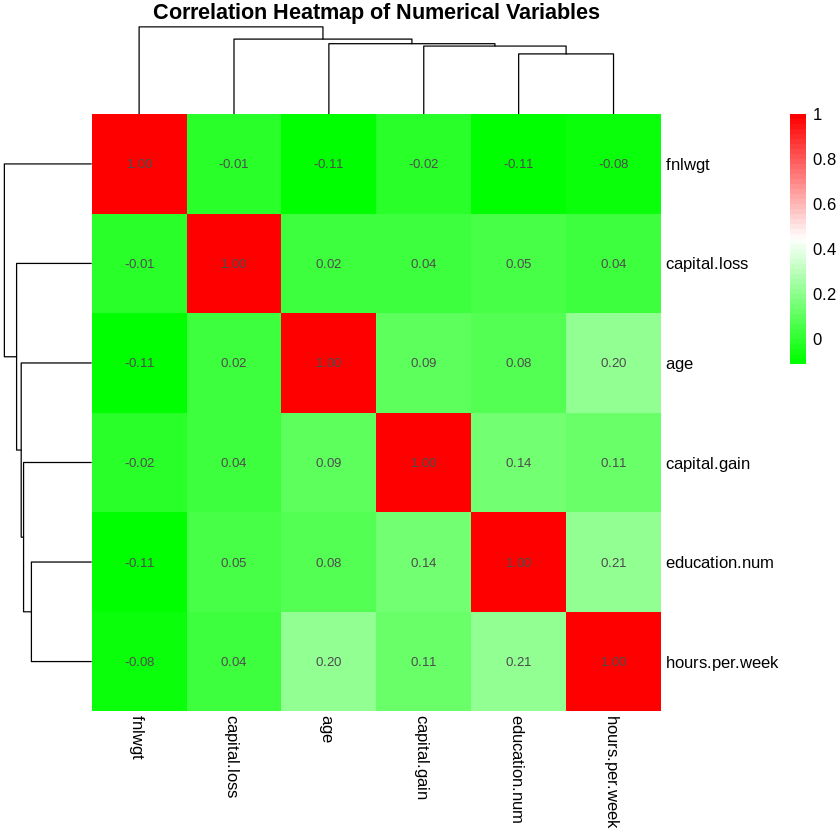

In [ ]:
numerical_data <- train_data[sapply(train_data, is.numeric)]

cor_matrix <- cor(numerical_data)
pheatmap(cor_matrix,
         cluster_rows = TRUE,
         cluster_cols = TRUE,
         display_numbers = TRUE,
         color = colorRampPalette(c("green", "white", "red"))(50),
         main = "Correlation Heatmap of Numerical Variables",
         border_color = NA)

In [ ]:
# Select numerical columns for the scatter plot matrix
numerical_cols <- c("age", "fnlwgt", "education.num", "capital.gain", "capital.loss", "hours.per.week")

scatter_plot <- ggpairs(train_data[, numerical_cols],
                        upper = list(continuous = wrap("cor", size = 3)),  # Correlation in upper panel
                        lower = list(continuous = wrap("smooth", method = "lm", color = "red", se = FALSE)),  # Red regression line
                        diag = list(continuous = wrap("barDiag", fill = "blue")),  # Blue histograms in diagonal
                        title = "Scatter Plot Matrix of Numerical Features") +
              theme_minimal()

# Save the plot
ggsave("scatter_matrix.png", plot = scatter_plot, width = 15, height = 10, dpi = 300)

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


In [ ]:
head(train_data)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
,<int>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>
1,52,Private,98926,HS-grad,9,unmarried,Other-service,Unmarried,White,Male,-3,0,44,USA,<=50K
2,76,Self-employed,132607,degree-holder,12,married,Sales,Husband,White,Male,7527,0,44,USA,>50K
3,40,Private,243258,degree-holder,13,married,Transport-moving,Husband,Other,Male,19,0,57,USA,>50K
4,76,Government,181259,degree-holder,12,married,Prof-specialty,Husband,White,Male,7720,0,44,USA,>50K
6,24,Private,274505,degree-holder,12,unmarried,Prof-specialty,Own-child,White,Female,2,0,40,USA,<=50K
7,40,Private,80789,HS-grad,8,married,Adm-clerical,Wife,White,Female,13,0,35,USA,>50K


In [ ]:
# Example data frame with 10 categorical variables (replace with your actual data)
categorical_vars <- c("workclass", "education", "marital.status", "occupation", "relationship",
                      "race", "sex", "native.country", "income")

# Create an empty matrix to store Cramér's V values
cramer_matrix <- matrix(NA, nrow = length(categorical_vars), ncol = length(categorical_vars),
                        dimnames = list(categorical_vars, categorical_vars))

# Loop through all pairs of categorical variables
for (i in 1:length(categorical_vars)) {
  for (j in 1:length(categorical_vars)) {
    if (i != j) {  # Avoid diagonal (self-comparison)
      tbl <- table(train_data[[categorical_vars[i]]], train_data[[categorical_vars[j]]])  # Contingency table
      cramer_matrix[i, j] <- assocstats(tbl)$cramer  # Compute Cramér's V
    } else {
      cramer_matrix[i, j] <- 1  # Perfect correlation with itself
    }
  }
}

# Print the Cramér's V correlation matrix
print(cramer_matrix)

                workclass education marital.status occupation relationship
workclass      1.00000000 0.1257909     0.18989316  0.2285332    0.1844630
education      0.12579091 1.0000000     0.11853034  0.3126110    0.1455670
marital.status 0.18989316 0.1185303     1.00000000  0.2349307    0.7094952
occupation     0.22853319 0.3126110     0.23493071  1.0000000    0.2041233
relationship   0.18446299 0.1455670     0.70949525  0.2041233    1.0000000
race           0.09380487 0.1384573     0.13439247  0.1496294    0.1814972
sex            0.25481517 0.1018636     0.45079813  0.4021764    0.6103491
native.country 0.13188423 0.1078337     0.04382153  0.1565352    0.1617039
income         0.20953866 0.2755707     0.44982776  0.3442784    0.4751529
                     race        sex native.country     income
workclass      0.09380487 0.25481517     0.13188423 0.20953866
education      0.13845734 0.10186361     0.10783372 0.27557073
marital.status 0.13439247 0.45079813     0.04382153 0.4498277

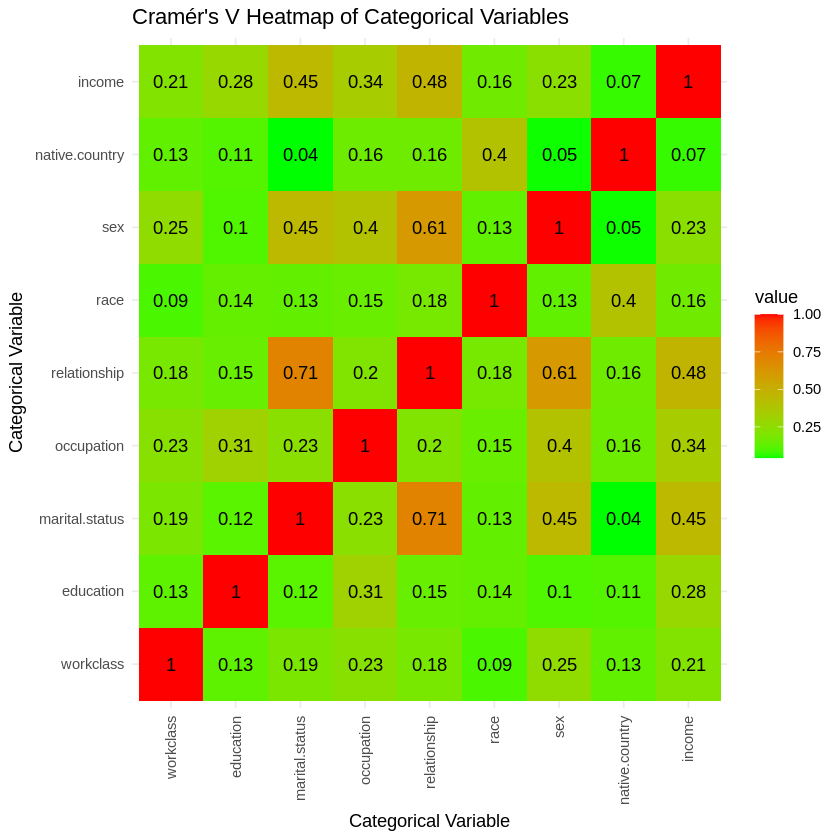

In [ ]:
# Convert matrix to long format for ggplot
cramer_df <- melt(cramer_matrix)

# Plot heatmap
ggplot(cramer_df, aes(Var1, Var2, fill = value)) +
  geom_tile() +
  geom_text(aes(label = round(value, 2)), color = "black") +  # Add correlation values
  scale_fill_gradient(low = "green", high = "red") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)) +
  labs(title = "Cramér's V Heatmap of Categorical Variables", x = "Categorical Variable", y = "Categorical Variable")


PLS model (class pls) summary
-------------------------------
Info: PLS Regression for Working Hours
Number of selected components: 7
Cross-validation: random with 5 segments

    X cumexpvar Y cumexpvar    R2  RMSE Slope    Bias  RPD
Cal    29.95602    23.07069 0.231 9.794 0.231  0.0000 1.14
Cv           NA          NA 0.226 9.823 0.229 -0.0014 1.14



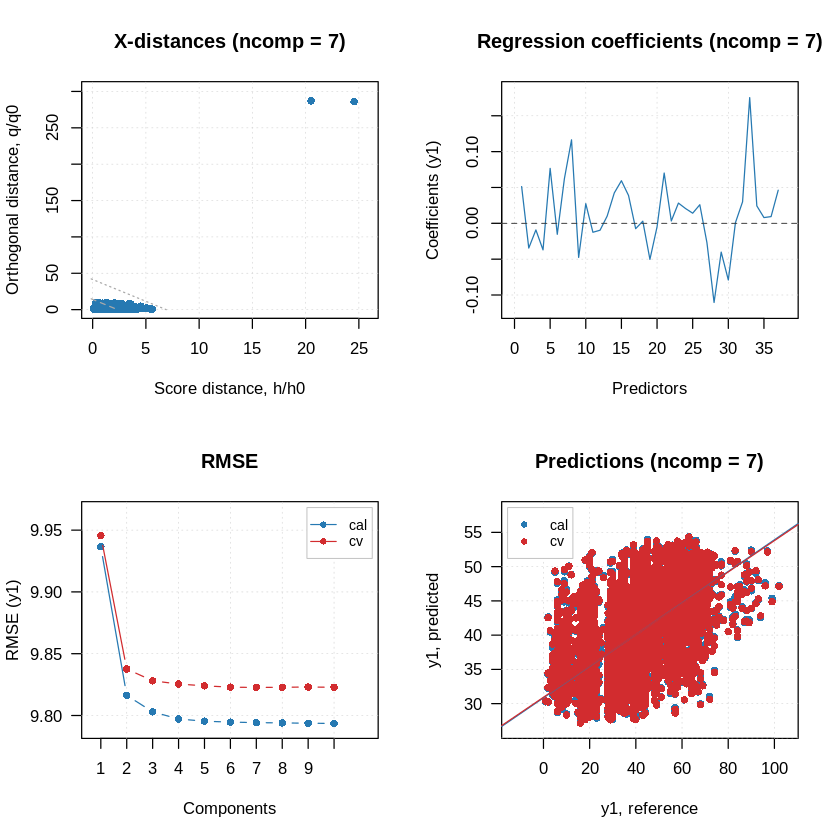

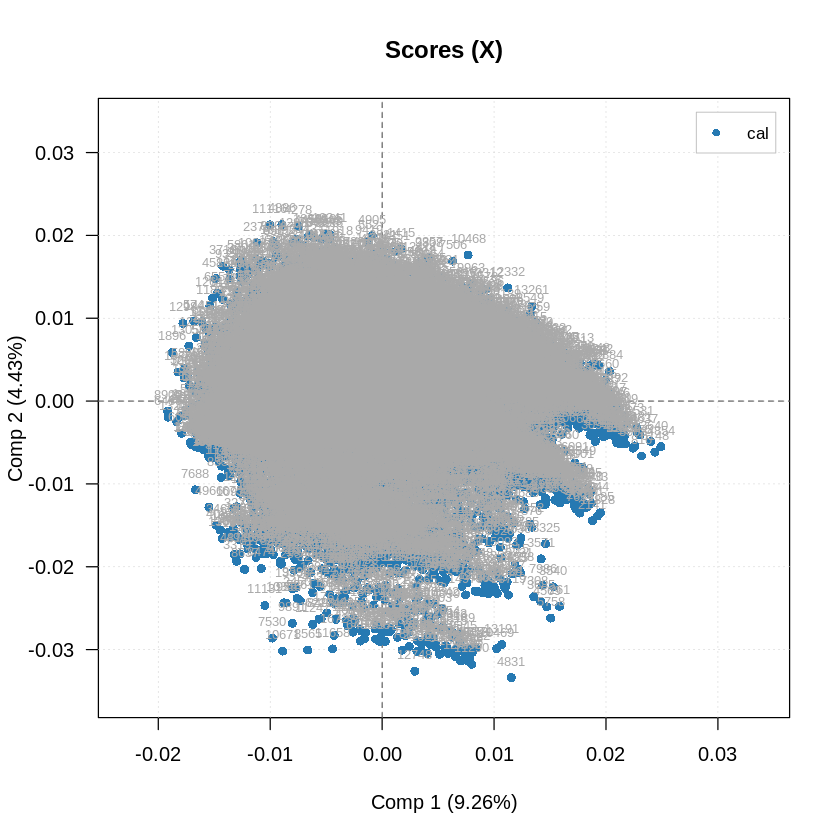

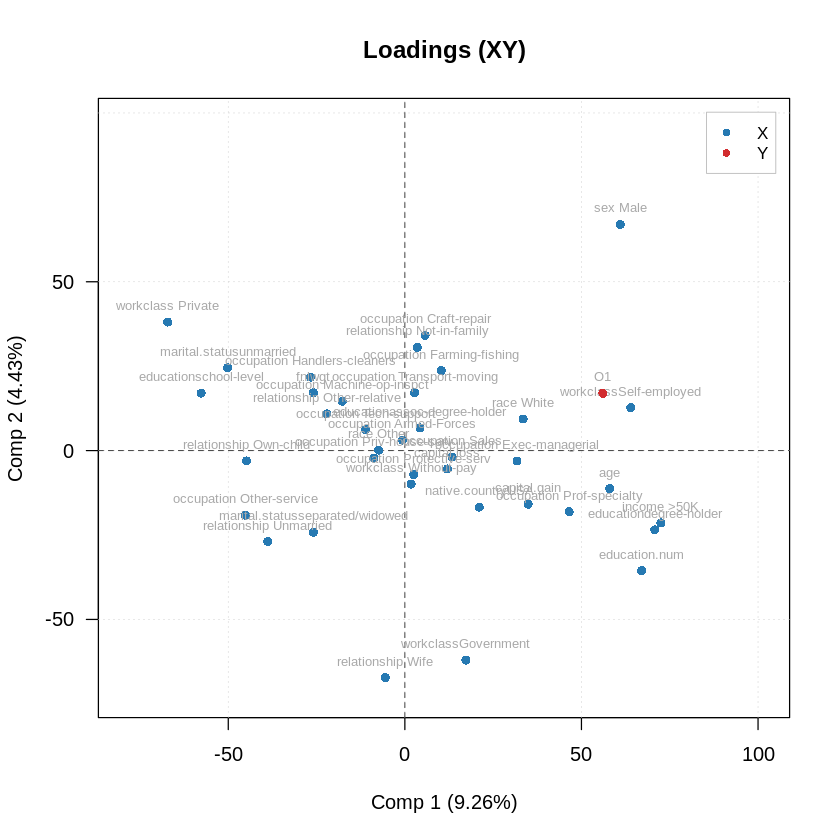

In [ ]:
# Convert categorical variables to factors
train_data[] <- lapply(train_data, function(x) if(is.character(x)) as.factor(x) else x)

# Define target variable
yt <- train_data$hours.per.week  # Target variable

# Remove target variable from feature set
Xt <- train_data[, !names(train_data) %in% c("hours.per.week")]

# Convert categorical variables into dummy variables
Xt <- model.matrix(~ . - 1, data = Xt)  # One-hot encoding

# Fit PLS model
pls_model <- pls(Xt, yt, scale = TRUE, cv = 5, ncomp = 10, info = "PLS Regression for Working Hours")

# Model summary
summary(pls_model)

# Visualizations
plot(pls_model)  # General model performance plot
plotXScores(pls_model, show.labels = TRUE)  # X-scores plot
plotXYLoadings(pls_model, show.labels = TRUE)  # Loadings plot

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘lazyeval’, ‘crosstalk’, ‘estimability’, ‘mvtnorm’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘ggrepel’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘corrplot’, ‘viridis’, ‘ggsci’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’, ‘plyr’, ‘dendextend’, ‘ggpubr’, ‘reshape2’


Loading required package: ggplot2

Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa




Call:
MCA(X = categorical_col, graph = FALSE) 


Eigenvalues
                       Dim.1   Dim.2   Dim.3   Dim.4   Dim.5   Dim.6   Dim.7
Variance               0.341   0.204   0.182   0.172   0.146   0.129   0.127
% of var.              9.910   5.920   5.294   4.986   4.248   3.753   3.700
Cumulative % of var.   9.910  15.831  21.125  26.111  30.359  34.112  37.812
                       Dim.8   Dim.9  Dim.10  Dim.11  Dim.12  Dim.13  Dim.14
Variance               0.121   0.119   0.114   0.113   0.112   0.111   0.111
% of var.              3.500   3.454   3.321   3.268   3.253   3.236   3.234
Cumulative % of var.  41.312  44.765  48.086  51.354  54.607  57.843  61.077
                      Dim.15  Dim.16  Dim.17  Dim.18  Dim.19  Dim.20  Dim.21
Variance               0.110   0.109   0.105   0.103   0.102   0.096   0.096
% of var.              3.201   3.157   3.038   3.001   2.974   2.800   2.784
Cumulative % of var.  64.279  67.435  70.473  73.474  76.448  79.248  82.032
              

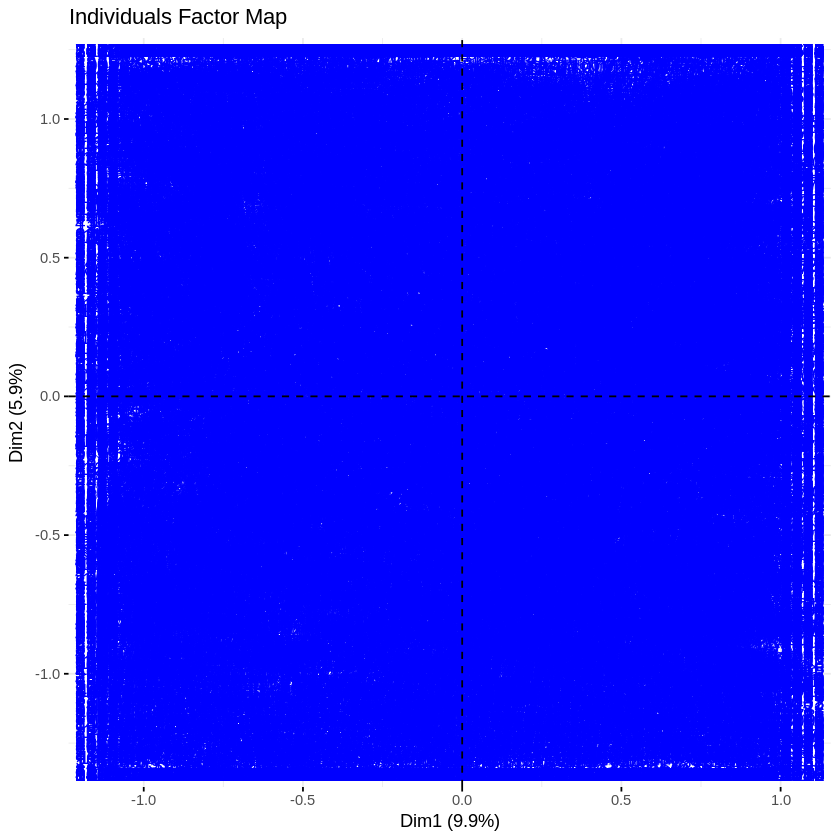

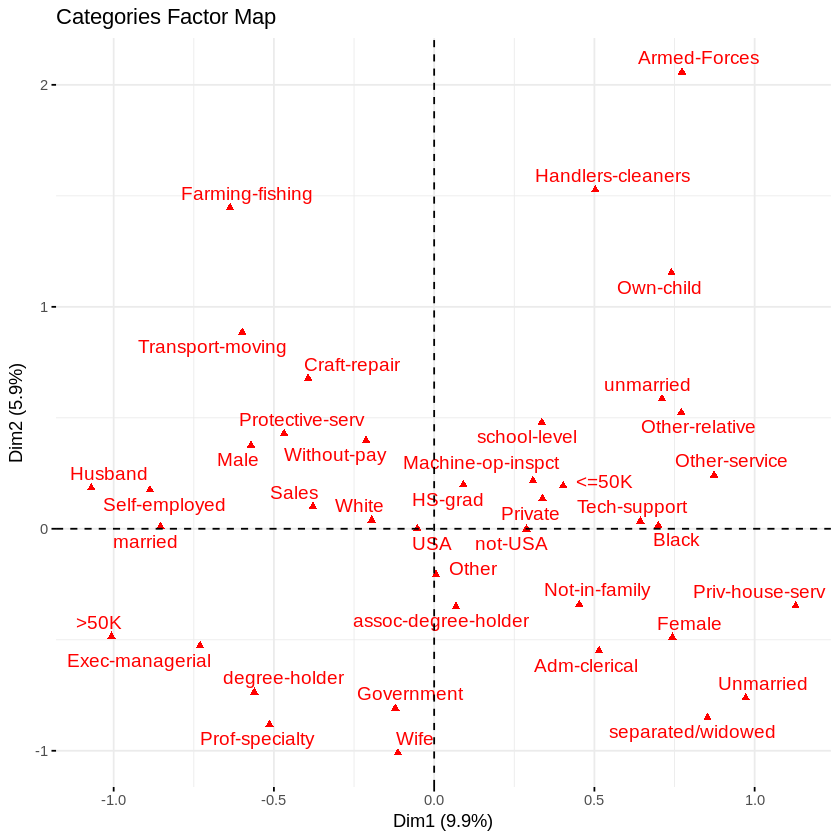

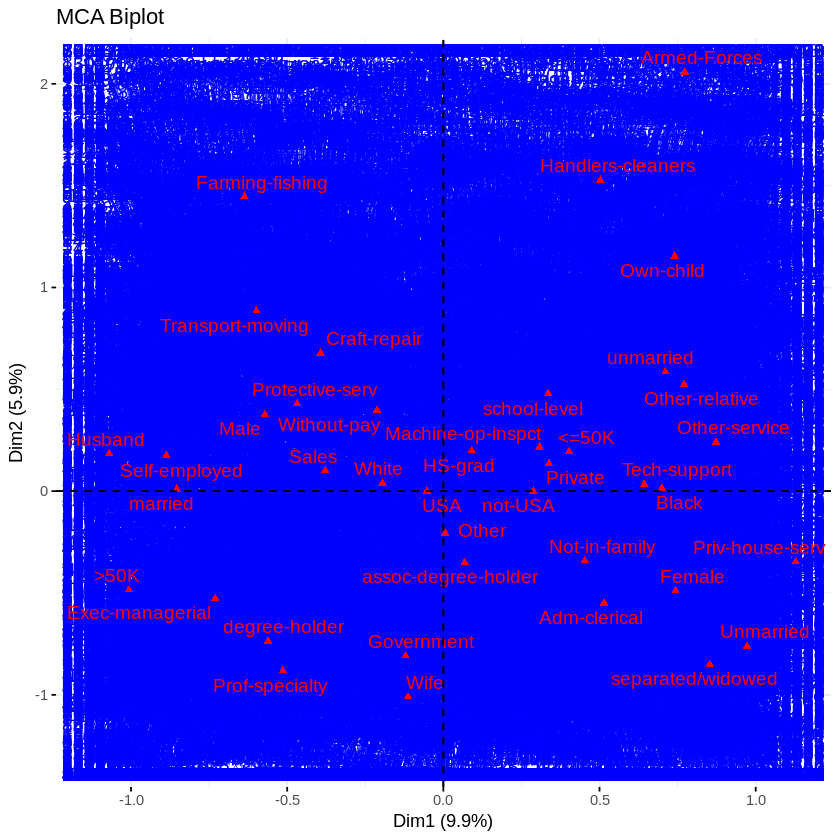

In [ ]:
install.packages("FactoMineR")
install.packages("factoextra")
library(FactoMineR)
library(factoextra)

# Load dataset (assuming df contains only categorical variables)
categorical_col <- train_data[, sapply(train_data, is.factor)]  # Select only categorical columns

# Run MCA
mca_model <- MCA(categorical_col, graph = FALSE)

# Summary of MCA
summary(mca_model)

# Plot individuals
fviz_mca_ind(mca_model, repel = TRUE,
             title = "Individuals Factor Map")

# Plot variables (categories)
fviz_mca_var(mca_model, repel = TRUE,
             title = "Categories Factor Map")

# Biplot (Individuals + Categories)
fviz_mca_biplot(mca_model, repel = TRUE,
                title = "MCA Biplot")




Call:
FAMD(base = train_data, graph = FALSE) 


Eigenvalues
                      Dim.1  Dim.2  Dim.3  Dim.4  Dim.5
Variance              3.721  2.235  1.909  1.578  1.378
% of var.            10.057  6.039  5.160  4.265  3.723
Cumulative % of var. 10.057 16.096 21.257 25.521 29.244

Individuals (the 10 first)
                        Dist    Dim.1    ctr   cos2    Dim.2    ctr   cos2  
1                   |  4.587 | -1.030  0.002  0.050 | -0.288  0.000  0.004 |
2                   |  6.185 |  4.316  0.033  0.487 | -0.008  0.000  0.000 |
3                   |  6.599 |  2.681  0.013  0.165 | -0.556  0.001  0.007 |
4                   |  6.131 |  4.168  0.031  0.462 |  1.565  0.007  0.065 |
5                   |  4.767 | -0.909  0.001  0.036 |  1.655  0.008  0.121 |
6                   |  5.455 |  0.137  0.000  0.001 |  0.442  0.001  0.007 |
7                   |  7.080 | -1.058  0.002  0.022 |  1.509  0.007  0.045 |
8                   |  5.843 |  2.380  0.010  0.166 |  0.517  0.001  0.

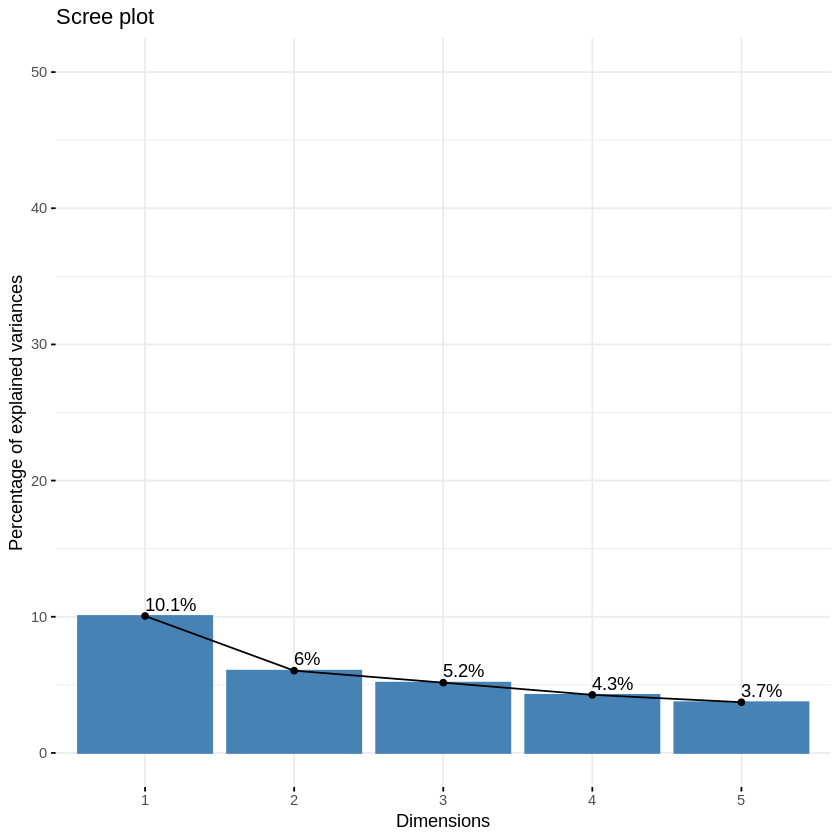

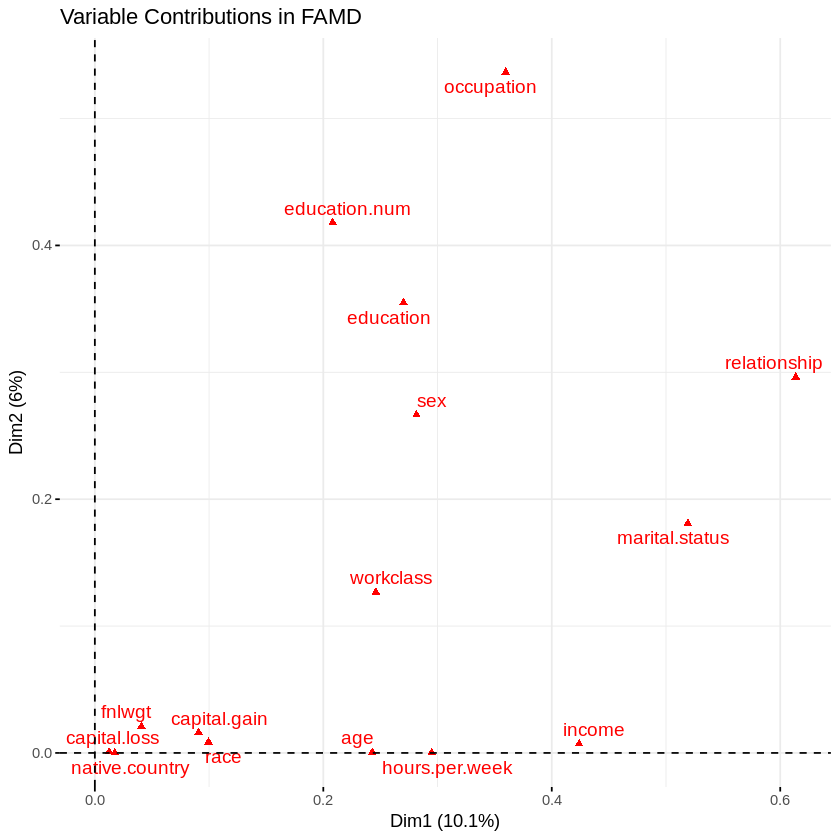

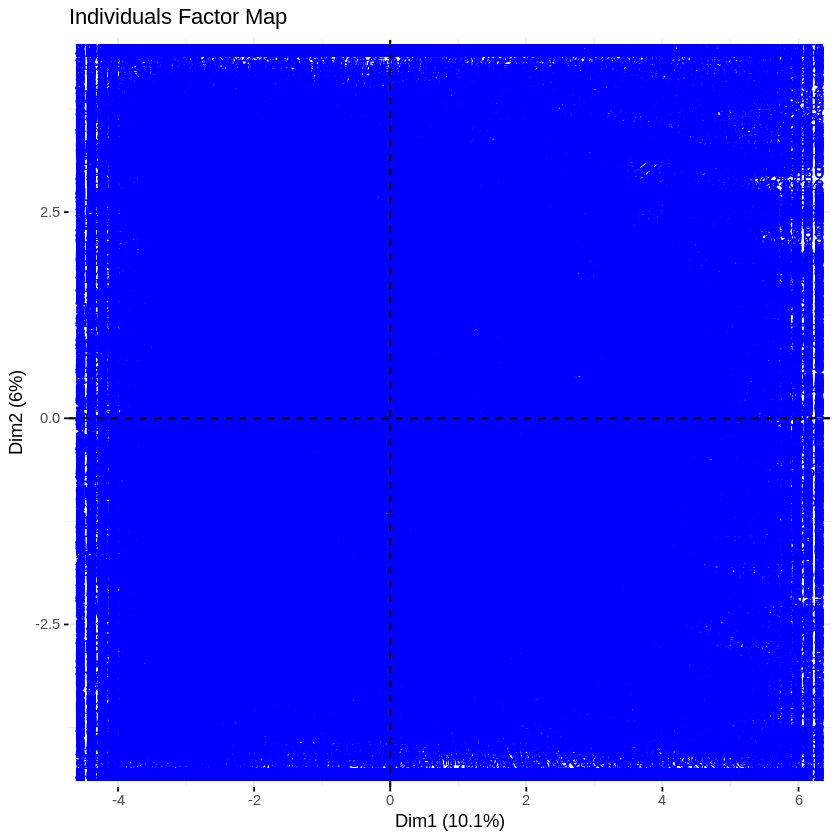

In [ ]:
train_data <- read.csv("train_data.csv")
# Convert categorical variables to factors
train_data[sapply(train_data, is.character)] <- lapply(train_data[sapply(df, is.character)], as.factor)

# Apply FAMD
famd_model <- FAMD(train_data, graph = FALSE)

# View summary
summary(famd_model)

fviz_screeplot(famd_model, addlabels = TRUE, ylim = c(0, 50))
fviz_famd_var(famd_model, repel = TRUE, title = "Variable Contributions in FAMD")
fviz_famd_ind(famd_model, repel = TRUE, title = "Individuals Factor Map")

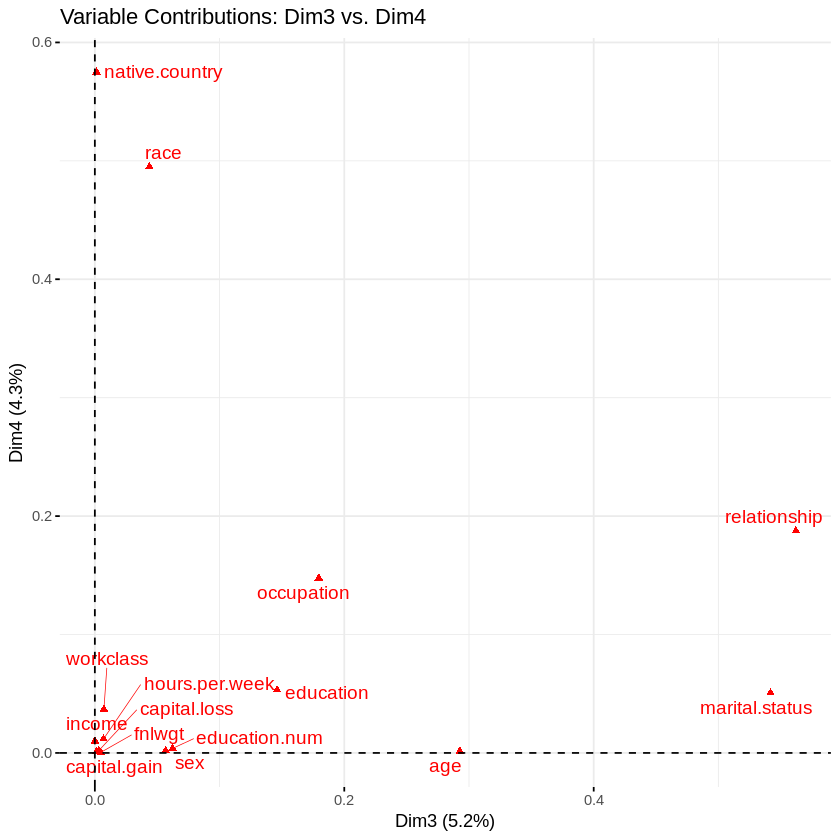

In [ ]:
fviz_famd_var(famd_model, axes = c(3, 4), repel = TRUE, title = "Variable Contributions: Dim3 vs. Dim4")


                       age       fnlwgt education.num capital.gain capital.loss
age             1.00000000 -0.092071852    0.08799592  0.093045084   0.01583761
fnlwgt         -0.09207185  1.000000000   -0.10249074 -0.003549054  -0.01052138
education.num   0.08799592 -0.102490743    1.00000000  0.029712968   0.01254372
capital.gain    0.09304508 -0.003549054    0.02971297  1.000000000   0.01504387
capital.loss    0.01583761 -0.010521383    0.01254372  0.015043875   1.00000000
hours.per.week  0.22140691 -0.082250301    0.24361966  0.100005981   0.01174967
               hours.per.week
age                0.22140691
fnlwgt            -0.08225030
education.num      0.24361966
capital.gain       0.10000598
capital.loss       0.01174967
hours.per.week     1.00000000


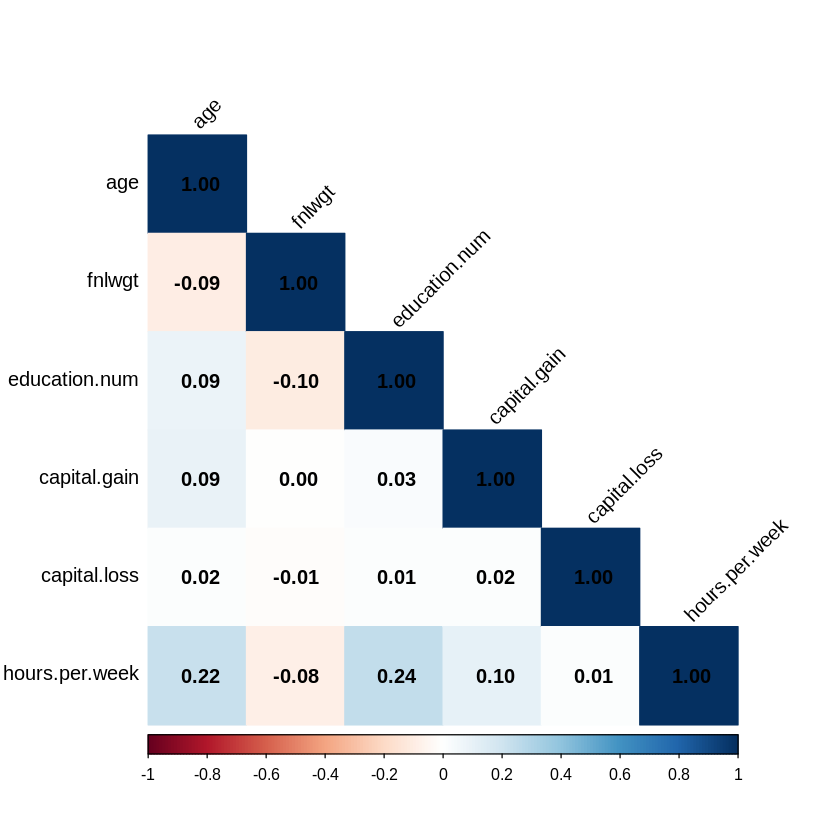

In [ ]:
train_data <- read.csv("/content/train_data.csv")
numerical_data <- train_data[sapply(train_data, is.numeric)]

# Compute Spearman's correlation matrix
spearman_corr <- cor(numerical_data, method = "spearman")

# Print the correlation matrix
print(spearman_corr)

corrplot(spearman_corr, method = "color", type = "lower",
         tl.col = "black", tl.srt = 45, addCoef.col = "black")

In [ ]:
# Install and load Hmisc package
install.packages("Hmisc")
library(Hmisc)

# Compute Spearman's correlation with p-values
spearman_results <- rcorr(as.matrix(numerical_data), type = "spearman")

# Print correlation coefficients
print(spearman_results$r)

# Print p-values
print(spearman_results$P)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘checkmate’, ‘gridExtra’, ‘htmlTable’, ‘viridis’, ‘Formula’



Attaching package: ‘Hmisc’


The following objects are masked from ‘package:dplyr’:

    src, summarize


The following objects are masked from ‘package:base’:

    format.pval, units




                       age       fnlwgt education.num capital.gain capital.loss
age             1.00000000 -0.092071852    0.08799592  0.093045084   0.01583761
fnlwgt         -0.09207185  1.000000000   -0.10249074 -0.003549054  -0.01052138
education.num   0.08799592 -0.102490743    1.00000000  0.029712968   0.01254372
capital.gain    0.09304508 -0.003549054    0.02971297  1.000000000   0.01504387
capital.loss    0.01583761 -0.010521383    0.01254372  0.015043875   1.00000000
hours.per.week  0.22140691 -0.082250301    0.24361966  0.100005981   0.01174967
               hours.per.week
age                0.22140691
fnlwgt            -0.08225030
education.num      0.24361966
capital.gain       0.10000598
capital.loss       0.01174967
hours.per.week     1.00000000
                      age    fnlwgt education.num capital.gain capital.loss
age                    NA 0.0000000  0.0000000000 0.0000000000   0.05160169
fnlwgt         0.00000000        NA  0.0000000000 0.6627260932   0.19599999
ed

In [ ]:
#install.packages("car")
library(car)
# Convert categorical variables to factors
train_data[, c("workclass", "education", "marital.status", "occupation", "race", "sex", "native.country", "income", "relationship")] <-
  lapply(train_data[, c("workclass", "education", "marital.status", "occupation", "race", "sex", "native.country", "income", "relationship")], as.factor)

# Fit a regression model with numerical and categorical variables
full_model <- lm(hours.per.week ~ ., data = train_data)  # Use one numerical target for assessment

# Compute GVIF (Generalized VIF)
gvif_values <- vif(full_model)
print(gvif_values)

                   GVIF Df GVIF^(1/(2*Df))
age            1.477098  1        1.215359
workclass      1.377937  3        1.054884
fnlwgt         1.063608  1        1.031314
education      2.470229  3        1.162669
education.num  2.243541  1        1.497845
marital.status 6.552244  2        1.599917
occupation     2.470452 13        1.035397
relationship   9.367577  5        1.250728
race           1.372179  2        1.082312
sex            1.770184  1        1.330483
capital.gain   1.085497  1        1.041872
capital.loss   1.012404  1        1.006183
native.country 1.302422  1        1.141237
income         1.542422  1        1.241943


In [ ]:
# Sample data
train_data <- read.csv("/content/train_data.csv")
numerical_data <- train_data[sapply(train_data, is.numeric)]

# Install and load Hmisc package
install.packages("Hmisc")
library(Hmisc)

# Compute Spearman's correlation with p-values
pearson_results <- rcorr(as.matrix(numerical_data), type = "pearson")

# Print correlation coefficients
print(pearson_results$r)

# Print p-values
print(pearson_results$P)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘checkmate’, ‘gridExtra’, ‘htmlTable’, ‘viridis’, ‘Formula’



Attaching package: ‘Hmisc’


The following objects are masked from ‘package:base’:

    format.pval, units




                       age      fnlwgt education.num capital.gain capital.loss
age             1.00000000 -0.11167926    0.07521886   0.08865017   0.02385757
fnlwgt         -0.11167926  1.00000000   -0.11342593  -0.02213207  -0.00867519
education.num   0.07521886 -0.11342593    1.00000000   0.14215957   0.05396893
capital.gain    0.08865017 -0.02213207    0.14215957   1.00000000   0.04138972
capital.loss    0.02385757 -0.00867519    0.05396893   0.04138972   1.00000000
hours.per.week  0.20236586 -0.07874355    0.21429079   0.11133109   0.03837026
               hours.per.week
age                0.20236586
fnlwgt            -0.07874355
education.num      0.21429079
capital.gain       0.11133109
capital.loss       0.03837026
hours.per.week     1.00000000
                       age      fnlwgt education.num capital.gain capital.loss
age                     NA 0.000000000  0.000000e+00 0.000000e+00 3.364314e-03
fnlwgt         0.000000000          NA  0.000000e+00 6.524381e-03 2.863633e-01
